### Tutorial 1 — Ingest a slide into CORAL

**CORAL** is the spatial-proteomics counterpart to
[TRIDENT](https://github.com/mahmoodlab/TRIDENT) (computational pathology).

This tutorial walks a single multiplex slide through the **ingest** process, which is the entry point for CORAL processing:

> **Runs on the cHL CODEX slide from Tutorial 0.** Run
> [Tutorial 0](0-Example-Data-Download.ipynb) first — it downloads the
> dataset (~3.4 GB, one time) into `tutorials/example-data/` and nests the
> slide under `cohort/`. **Launch Jupyter from the `tutorials/` directory**,
> and run the `coral` commands below from a terminal at the repo root
> (`CORAL/`) — the same place you ran `uv sync`. To use your own data,
> point `--image-dir` at any OME-TIFF / QPTIFF / MIBI / OME-Zarr (or a
> directory of per-channel TIFFs) and set `--mpp` to its pixel size.

CORAL gives you the same ingest two ways. This tutorial leads with the
**command line** (run in a terminal), then shows the equivalent **Python** API,
and finally opens the ingested slide to inspect it.

| Step   | CLI          | Python                      |
| ------ | ------------ | --------------------------- |
| Ingest | `coral ingest` | `convert_to_canonical(...)` |
| Status | `coral status` | `slide.status()`            |

#### 0 — Installation

```bash
# Base install — CORAL's core tools work out of the box (pure NumPy)
uv sync
```

In [1]:
from pathlib import Path

# Run this notebook from the tutorials/ directory (Jupyter's working dir).
# The Section 1 coral command runs from the repo root and writes to
# tutorials/example-data/processed — which, from here, is example-data/processed.
OUTPUT_DIR = Path("example-data/processed")
MPP = 0.37          # CODEX pixel size for this dataset (um/px)
PATCH_SIZE = 256    # 256 px is ~95 um at this mpp

# Inline figures as JPEG, not PNG to keep the file size small.
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"bbox_inches": "tight", "facecolor": "white", "pil_kwargs": {"quality": 85}}


#### 1. Ingest from the command line

Real multiplex images are messy: QPTIFF, OME-TIFF with arbitrary axis order,
or — like this cHL dataset — a **directory of one single-channel TIFF per
marker**. `coral ingest` is CORAL's format adapter. For every slide under
`--image-dir` it:

- reads the source,
- reorders axes to the canonical `(c, y, x)` layout,
- resolves each channel's marker name against CORAL's [marker registry](../src/coral/markers/data/registry_v1.csv),
- identifies the nuclear stain,
- records provenance,
- and writes an OME-Zarr store into the `--job-dir`.

Run the commands below **from a terminal at the repo root** (`CORAL/`) —
where you ran `uv sync`. Paths are relative to that root, so they carry a
`tutorials/` prefix. Because `coral ingest` reads a *directory of slides*, we
point `--image-dir` at the `cohort/` folder Tutorial 0 created — it holds just
our one slide.

**Build the marker map.** The first pass reads channel names only (instant, no
pixels) and writes `marker_map.csv`:

```bash
uv run coral ingest --image-dir tutorials/example-data/cHL_CODEX/cohort --job-dir tutorials/example-data/processed --mpp 0.37
```

CORAL matches every raw name against its registry, and a handful don't resolve —
including the nuclear stain `DAPI-01`. Since CORAL won't ingest a slide whose
nuclear channel it can't resolve, this pass **stops before reading pixels** and
prints a review gate (an `ERROR` line — expected here, not a failure).

**Review & fix.** Open `tutorials/example-data/processed/marker_map.csv` and
fill the `mapped_canonical_name` for each `REVIEW` row — the
[marker registry](../src/coral/markers/data/registry_v1.csv) lists every
canonical name CORAL recognizes. Four need a decision here:

| `original_name` | `mapped_canonical_name` | why |
| --------------- | ----------------------- | --- |
| `DAPI-01`       | `DAPI`                  | per-cycle nuclear re-stain |
| `Cytokeritin`   | `CYTOKERATIN`           | vendor typo |
| `VISA`          | `VISTA`                 | a.k.a. VSIR / B7-H5 |
| `Collagen 4`    | `COLLAGENiv`            | **collagen IV** — *not* the generic `COLLAGEN` CORAL lists first |

The suggestions CORAL offers are advisory — **the mapping is your call.**
`Collagen 4 → COLLAGENiv` is exactly the judgment call the review step exists
for. (Section 2 shows the same fix done in Python.)

**Re-run to ingest the pixels.** With every name resolved, re-run the *same*
command. It finds the nuclear stain, reads the full image (~6 GB, ~30 s), and
writes `raw_image.zarr` into `processed/` — the store every later stage (and
Tutorials 2–4) builds on:

```bash
uv run coral ingest --image-dir tutorials/example-data/cHL_CODEX/cohort --job-dir tutorials/example-data/processed --mpp 0.37
```

Re-running an already-ingested store never re-reads pixels — it just re-applies
the (edited) `marker_map.csv`. 

#### 2. The same ingest in Python

Section 1 ran ingest from the **command line**. The Python API does the *same*
three things — build the marker map, review, ingest — but **one slide at a
time**, returning an open `CoralSlide` in the same call.

One nice contrast: `convert_to_canonical` takes the per-channel `raw_image/`
directory **directly**. The CLI instead points at the `cohort/` folder
*containing* it, because it ingests a directory of slides; the Python call is
single-slide by design.

Shown here for reference — you already built the store from the terminal in
Section 1, so there's no need to run this:

```python
from pathlib import Path

from coral.io.ingest import convert_to_canonical, resolve_cohort_markers
from coral.markers.marker_map import read_marker_map, write_marker_map

raw_image_dir = Path("example-data/cHL_CODEX/cohort/raw_image")

# 1. Build marker_map.csv (channel names only — instant, no pixel read).
resolve_cohort_markers([raw_image_dir], OUTPUT_DIR)

# 2. Review & fix the flagged rows, then write the CSV back.
marker_map = read_marker_map(OUTPUT_DIR)
fixes = {"DAPI-01": "DAPI", "Cytokeritin": "CYTOKERATIN",
         "Collagen 4": "COLLAGENiv", "VISA": "VISTA"}
for raw_name, canonical in fixes.items():
    row = marker_map["original_name"] == raw_name
    marker_map.loc[row, "mapped_canonical_name"] = canonical
    marker_map.loc[row, "status"] = "RESOLVED"
write_marker_map(marker_map, OUTPUT_DIR)

# 3. Ingest the pixels — point straight at the per-channel directory.
slide = convert_to_canonical(
    raw_image_dir, OUTPUT_DIR, mpp=MPP, nuclear_marker="DAPI",
)
```

#### 3. Image inspection

Here is the `CoralSlide` you created in Section 1. Let's inspect it — first the
marker list, then the nuclear channel, then a false-colour composite of several
markers.

In [2]:
from coral import CoralSlide

store_path = OUTPUT_DIR / "raw_image.zarr"
assert store_path.exists(), (
    f"No ingested slide at {store_path}. Run the coral ingest command in "
    "Section 1 (from your terminal) first."
)
slide = CoralSlide.open(store_path)

print(slide)                                          # CoralSlide(name=..., markers=N)
print("image (c,y,x):", slide.image.shape)
print("nuclear stain:", slide.markers[slide.nuclear_channel])
print("markers      :", ", ".join(slide.markers))

CoralSlide(name='raw_image', markers=49)
image (c,y,x): (49, 8011, 8085)
nuclear stain: dapi
markers      : bcl2, ccr6, cd11b, cd11c, cd15, cd16, cd162, cd163, cd2, cd20, cd206, cd25, cd30, cd31, cd4, cd44, cd45ra, cd45ro, cd46, cd5, cd56, cd57, cd68, cd69, cd7, cd8, collageniv, cytokeratin, dapi, egfr, foxp3, granzymeb, hla_dr, ido1, lag3, mct, mmp9, muc1, pd1, pdl1, podoplanin, tbet, tcr_gd, tcr_b, tim3, vista, vimentin, a_sma, b_catenin


**The nuclear channel.** CORAL keeps pixels lazy (Dask-backed Xarray), so `slide.image` is a `(c, y, x)` `DataArray` you can index by position. Let's look at the nuclear channel with CORAL's `normalize_uint8` helper.

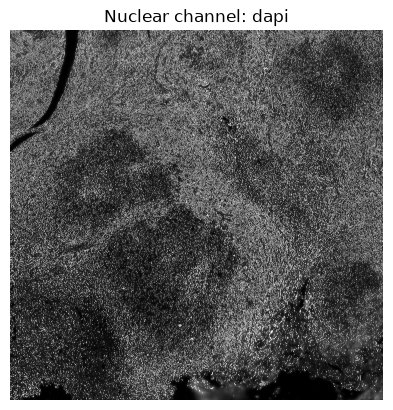

In [3]:
import matplotlib.pyplot as plt
from coral.viz import normalize_uint8

nuclear = slide.image[slide.nuclear_channel].values
plt.imshow(normalize_uint8(nuclear), cmap="gray")
plt.title(f"Nuclear channel: {slide.markers[slide.nuclear_channel]}")
plt.axis("off")
plt.show()

**Composite markers.** A quick visual check of several channels at once: three false-colour composites, each blending six markers in the KRONOS tutorial's palette (blue, red, green, yellow, magenta, cyan). We reuse that tutorial's `color_list` and its three marker sets, translated to CORAL's canonical names (`DAPI-01 → dapi`, `CYTOKERITIN → cytokeratin` — what `slide.markers` prints). Each channel is min–max stretched, tinted by its colour, and summed. A whole CODEX slide is large (here ~8000 × 8000 px), so we read a strided, **downsampled** view just for display.

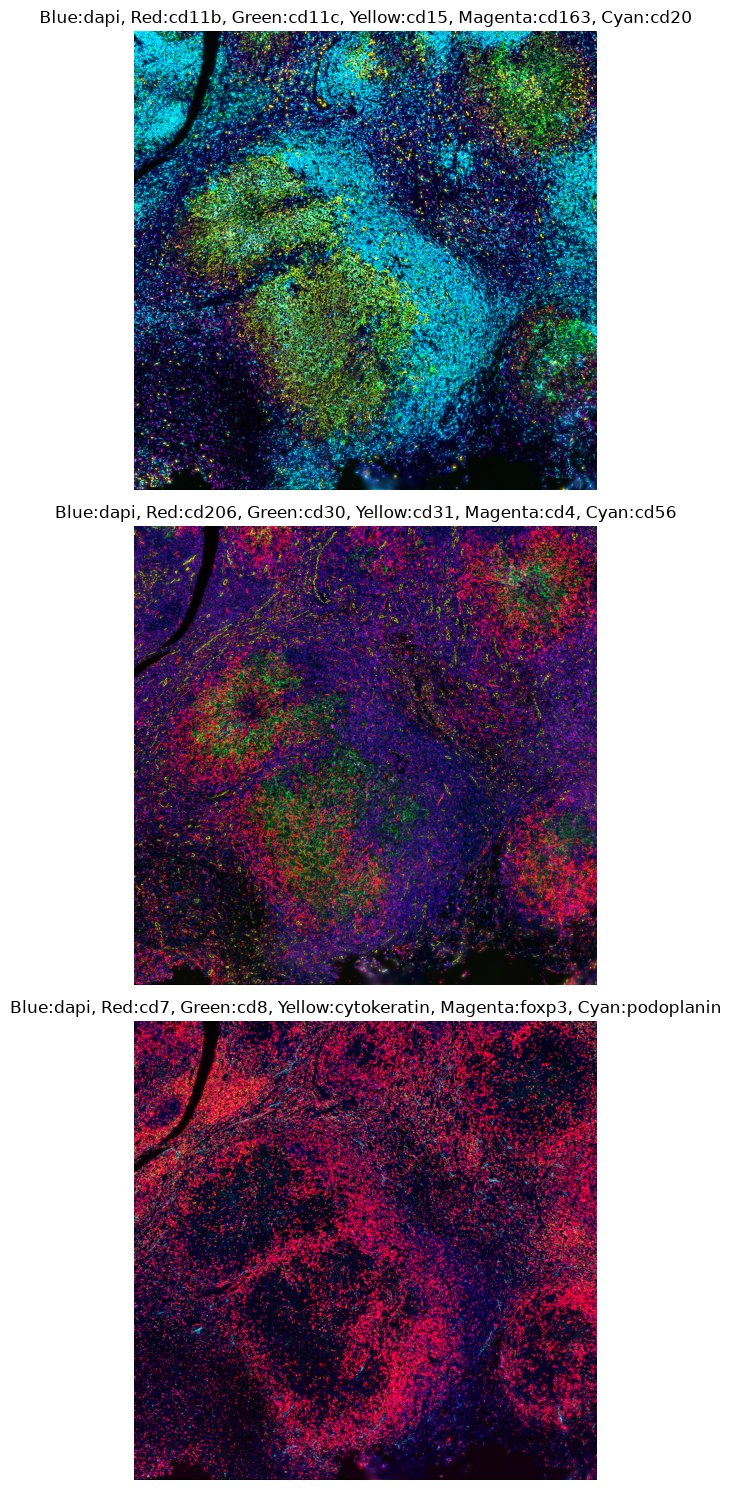

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from utils import composite

# Reuse the KRONOS tutorial's palette and three marker sets. CORAL
# canonicalises names at ingest, so DAPI-01 -> dapi and CYTOKERITIN ->
# cytokeratin (the names slide.markers prints).
colors = np.array([
    [0, 0, 255],    # Blue
    [255, 0, 0],    # Red
    [0, 255, 0],    # Green
    [255, 255, 0],  # Yellow
    [255, 0, 255],  # Magenta
    [0, 255, 255],  # Cyan
], dtype=np.float32)
color_list = ["Blue", "Red", "Green", "Yellow", "Magenta", "Cyan"]
marker_set_1 = ["dapi", "cd11b", "cd11c", "cd15", "cd163", "cd20"]
marker_set_2 = ["dapi", "cd206", "cd30", "cd31", "cd4", "cd56"]
marker_set_3 = ["dapi", "cd7", "cd8", "cytokeratin", "foxp3", "podoplanin"]

# composite() reads each marker and blends them (see tutorials/utils). A
# whole CODEX slide is large, so read a strided, downsampled view.
_, height, width = slide.image.shape
factor = max(1, int(np.ceil(max(height, width) / 1200)))

marker_sets = [marker_set_1, marker_set_2, marker_set_3]
fig, ax = plt.subplots(3, 1, figsize=(5, 15))
for a, mset in zip(ax, marker_sets):
    a.imshow(composite(slide, mset, colors, factor))
    a.set_title(", ".join(f"{c}:{m}" for c, m in zip(color_list, mset)),
                fontsize=12)
    a.axis("off")
plt.tight_layout()
plt.show()

#### 4. Recap

You took one raw multiplex image to a canonical CORAL slide — from the command line, and equivalently in Python. CORAL tracked every step in the slide's state file:

```bash
uv run coral status --job-dir tutorials/example-data/processed
```

Or through python API

In [6]:
{step: info["status"] for step, info in slide.status().items()}

{'ingest': 'completed', 'cells': 'pending'}

**Where next?**

- **Tutorial 2 — tissue, patches, and features.** Reopen this slide and run tissue segmentation → patch extraction → feature extraction (mean-marker and KRONOS2).
- **Cohorts**: point the `coral` CLI at a directory of slides, or drive `CoralProcessor` from Python, for parallel, resumable, per-slide-tracked runs.